In [20]:
# ======================================
# 1. OPTIONAL PACKAGE INSTALLATIONS
# Uncomment only if required
# ======================================

# !pip install -q xgboost
# !pip install -q lightgbm
# !pip install -q catboost
# !pip install -q shap
# !pip install -q lime
# !pip install -q imbalanced-learn
# !pip install -q optuna
# !pip install -q plotly
# !pip install -q missingno
# !pip install -q openpyxl
# !pip install -q xlsxwriter
# !pip install -q statsmodels
# !pip install -q tqdm

#print("✅ Package installation completed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [39]:
# ======================================
# 2. Core Libraries
# ======================================
import pandas as pd
import numpy as np

print("✅ Core Libraries imported successfully")

# ======================================
# Visualization
# ======================================
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Visualization Libraries imported successfully")

# ======================================
# Data Preprocessing
# ======================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

print("✅ Data Preprocessing Libraries imported successfully")

# ======================================
# Classification Models
# ======================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

print("✅ Classification Model Libraries imported successfully")

# ======================================
# Regression Models
# ======================================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

print("✅ Regression Model Libraries imported successfully")

# ======================================
# Boosting Models
# ======================================
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    catboost_available = True

except ImportError:
    catboost_available = False
    print("⚠️ CatBoost not available")

print("✅ Boosting Model Libraries imported successfully")

# ======================================
# Evaluation Metrics
# ======================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)

print("✅ Evaluation Metric Libraries imported successfully")

✅ Core Libraries imported successfully
✅ Visualization Libraries imported successfully
✅ Data Preprocessing Libraries imported successfully
✅ Classification Model Libraries imported successfully
✅ Regression Model Libraries imported successfully
✅ Boosting Model Libraries imported successfully
✅ Evaluation Metric Libraries imported successfully


In [22]:
# ======================================
# 3. GLOBAL CONSTANTS & DISPLAY SETTINGS
# ======================================

LINE = 70

DISPLAY_ROWS = 10
DISPLAY_COLUMNS = 50

pd.set_option('display.max_columns', DISPLAY_COLUMNS)
pd.set_option('display.max_rows', DISPLAY_ROWS)

def completion_message(task):
    print(f"✅ {task} completed successfully")

def section_end(section_no, section_name):
    print("=" * LINE)
    print(f"✅ SECTION {section_no} COMPLETED - {section_name.upper()}")
    print("=" * LINE)



In [44]:
# ======================================
# 4. PROJECT CONFIGURATION
# ======================================

import ipywidgets as widgets
from IPython.display import display


# --------------------------------------
# Interactive Dataset Configuration
# --------------------------------------

file_path_input = widgets.Text(
    value="",
    placeholder="",
    description="Dataset:",
    style={'description_width': 'initial'}
)


target_input = widgets.Text(
    value="",
    placeholder="",
    description="Target:",
    style={'description_width': 'initial'}
)


submit_button = widgets.Button(
    description="Submit Configuration"
)


display(file_path_input)
display(target_input)
display(submit_button)


def submit_configuration(b):

    global file_path
    global target

    file_path = file_path_input.value
    target = target_input.value

    print("=" * LINE)
    print("Configuration completed")
    print("Dataset:", file_path)
    print("Target :", target)
    print("=" * LINE)


submit_button.on_click(submit_configuration)


completion_message("✅ Dataset path configured and target set successfully!")


# --------------------------------------
# Automatic problem type detection
# (will be updated after dataset loading)
# --------------------------------------

problem_type = None


# --------------------------------------
# Other Configuration Settings
# --------------------------------------

test_size = 0.20

random_state = 42

cv_folds = 5


# Save trained model?

save_model = True


# Output filenames

model_filename = "best_model.pkl"

scaler_filename = "scaler.pkl"


# Enable plots

show_plots = True


# Enable feature importance

show_feature_importance = True

# Enable histogram plots
show_histograms = True

# Enable box plots
show_boxplots = True

# Enable correlation heatmap
show_correlation_heatmap = True

# Enable pairplot
show_pairplot = True

completion_message("✅ Project configuration completed!")

section_end(
    4,
    "Project Configuration"
)

Text(value='', description='Dataset:', placeholder='', style=DescriptionStyle(description_width='initial'))

Text(value='', description='Target:', placeholder='', style=DescriptionStyle(description_width='initial'))

Button(description='Submit Configuration', style=ButtonStyle())

✅ ✅ Dataset path configured and target set successfully! completed successfully
✅ ✅ Project configuration completed! completed successfully
✅ SECTION 4 COMPLETED - PROJECT CONFIGURATION
Configuration completed
Dataset: /content/diabetes.csv
Target : Diabetes
Configuration completed
Dataset: /content/diabetes.csv
Target : Diabetes
Configuration completed
Dataset: /content/diabetes.csv
Target : Outcome
Configuration completed
Dataset: /content/diabetes.csv
Target : Outcome


In [48]:
# ======================================
# 5. LOAD DATASET
# ======================================

# 5.1. Load dataset
df = pd.read_csv(file_path)

#Completion message
completion_message("✅ Dataset loaded successfully!")

✅ ✅ Dataset loaded successfully! completed successfully


In [27]:
# ======================================
#6. Verify Dataset
# ======================================

df.head()
df.tail()
df.sample(5)

completion_message("✅ Dataset verified successfully!")

section_end(5, "Dataset load")

✅ ✅ Dataset verified successfully! completed successfully
✅ SECTION 5 COMPLETED - DATASET LOAD


In [28]:
# ======================================
# 7. DATA EXPLORATION
# ======================================

# Dataset Shape
print("Dataset Shape:")
print(df.shape)

#Completion message
completion_message("✅ Dataset shape printed successfully!")

# Column Names
print("\nColumn Names:")
print(df.columns)

#Completion message
completion_message("✅ Column names printed successfully!")

# Dataset Information
print("\nDataset Information:")
df.info()

#Completion message
completion_message("✅ Dataset information printed successfully!")

# Summary Statistics
print("\nSummary Statistics:")
display(df.describe())

#Completion message
completion_message("✅ Summary statistics printed successfully!")

# Summary Statistics (Including Categorical Columns)
print("\nSummary Statistics (All Columns):")
display(df.describe(include='all'))

#Completion message
completion_message("✅ Summary statistics (all columns) printed successfully!")

# Data Types
print("\nData Types:")
display(df.dtypes)

#Completion message
completion_message("✅ Data types printed successfully!")

# Missing Values
print("\nMissing Values:")
display(df.isnull().sum())

#Completion message
completion_message("✅ Missing values printed successfully!")

# Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

#Completion message
completion_message("✅ Duplicate rows printed successfully!")

# Unique Values Per Column
print("\nUnique Values Per Column:")
display(df.nunique())

completion_message("✅ Unique values per column printed successfully!")

completion_message("✅ Data exploration completed successfully!")

section_end(7, "Data Exploration")


Dataset Shape:
(768, 9)
✅ ✅ Dataset shape printed successfully! completed successfully

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
✅ ✅ Column names printed successfully! completed successfully

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


✅ ✅ Summary statistics printed successfully! completed successfully

Summary Statistics (All Columns):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


✅ ✅ Summary statistics (all columns) printed successfully! completed successfully

Data Types:


...

✅ ✅ Data types printed successfully! completed successfully

Missing Values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


✅ ✅ Missing values printed successfully! completed successfully

Duplicate Rows:
0
✅ ✅ Duplicate rows printed successfully! completed successfully

Unique Values Per Column:


,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


✅ ✅ Unique values per column printed successfully! completed successfully
✅ ✅ Data exploration completed successfully! completed successfully
✅ SECTION 7 COMPLETED - DATA EXPLORATION


In [49]:
# ======================================
# 8. DATA CLEANING
# ======================================

# Create a copy of the original dataset
df_clean = df.copy()

#Completion message
completion_message("✅ Data cleaning copy created successfully!")

# -----------------------------
# Remove Duplicate Rows
# -----------------------------
duplicates_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
duplicates_after = df_clean.duplicated().sum()

print(f"Duplicates before: {duplicates_before}")
print(f"Duplicates after : {duplicates_after}")

#Completion message
completion_message("✅ Duplicate rows removed successfully!")


# -----------------------------
# Check Missing Values
# -----------------------------
print("\nMissing Values:")
display(df_clean.isnull().sum())

#Completion message
completion_message("✅ Missing values checked successfully!")

# -----------------------------
# Remove Rows with All Missing Values
# -----------------------------
df_clean.dropna(how='all', inplace=True)

#Completion message
completion_message("✅ Rows with all missing values removed successfully!")

# -----------------------------
# Remove Columns with All Missing Values
# -----------------------------
df_clean.dropna(axis=1, how='all', inplace=True)

#Completion message
completion_message("✅ Columns with all missing values removed successfully!")

# -----------------------------
# Verify Dataset After Cleaning
# -----------------------------
print("\nDataset Shape After Cleaning:")
print(df_clean.shape)

#Completion message
completion_message("✅ Dataset after cleaning verified successfully!")


#Completion message
completion_message("✅ Data cleaning completed successfully!")

section_end(8, "Data Cleaning")

✅ ✅ Data cleaning copy created successfully! completed successfully
Duplicates before: 0
Duplicates after : 0
✅ ✅ Duplicate rows removed successfully! completed successfully

Missing Values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


✅ ✅ Missing values checked successfully! completed successfully
✅ ✅ Rows with all missing values removed successfully! completed successfully
✅ ✅ Columns with all missing values removed successfully! completed successfully

Dataset Shape After Cleaning:
(768, 9)
✅ ✅ Dataset after cleaning verified successfully! completed successfully
✅ ✅ Data cleaning completed successfully! completed successfully
✅ SECTION 8 COMPLETED - DATA CLEANING


In [50]:
# ======================================
# 9. EXPLORATORY DATA ANALYSIS (EDA)
# ======================================

# Use the cleaned dataset
data = df_clean

#Completion message
completion_message("✅ Data loaded for EDA successfully!")

✅ ✅ Data loaded for EDA successfully! completed successfully


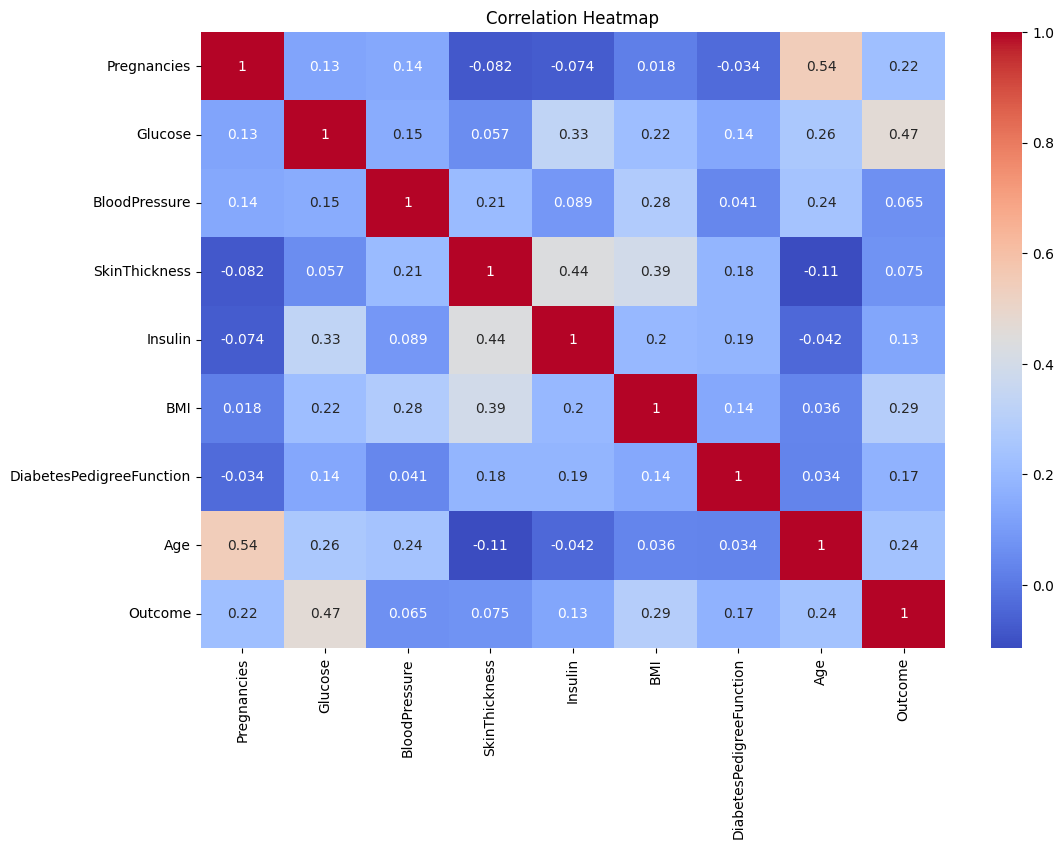

✅ ✅ Correlation heatmap printed successfully! completed successfully


In [51]:
# ======================================
#9.1. Correlation Heatmap (Numeric Columns)
# ======================================

if show_correlation_heatmap:

    plt.figure(figsize=(12,8))

    correlation = df.select_dtypes(include=np.number).corr()

    sns.heatmap(
        correlation,
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Correlation Heatmap")
    plt.show()

#Completion message
completion_message("✅ Correlation heatmap printed successfully!")


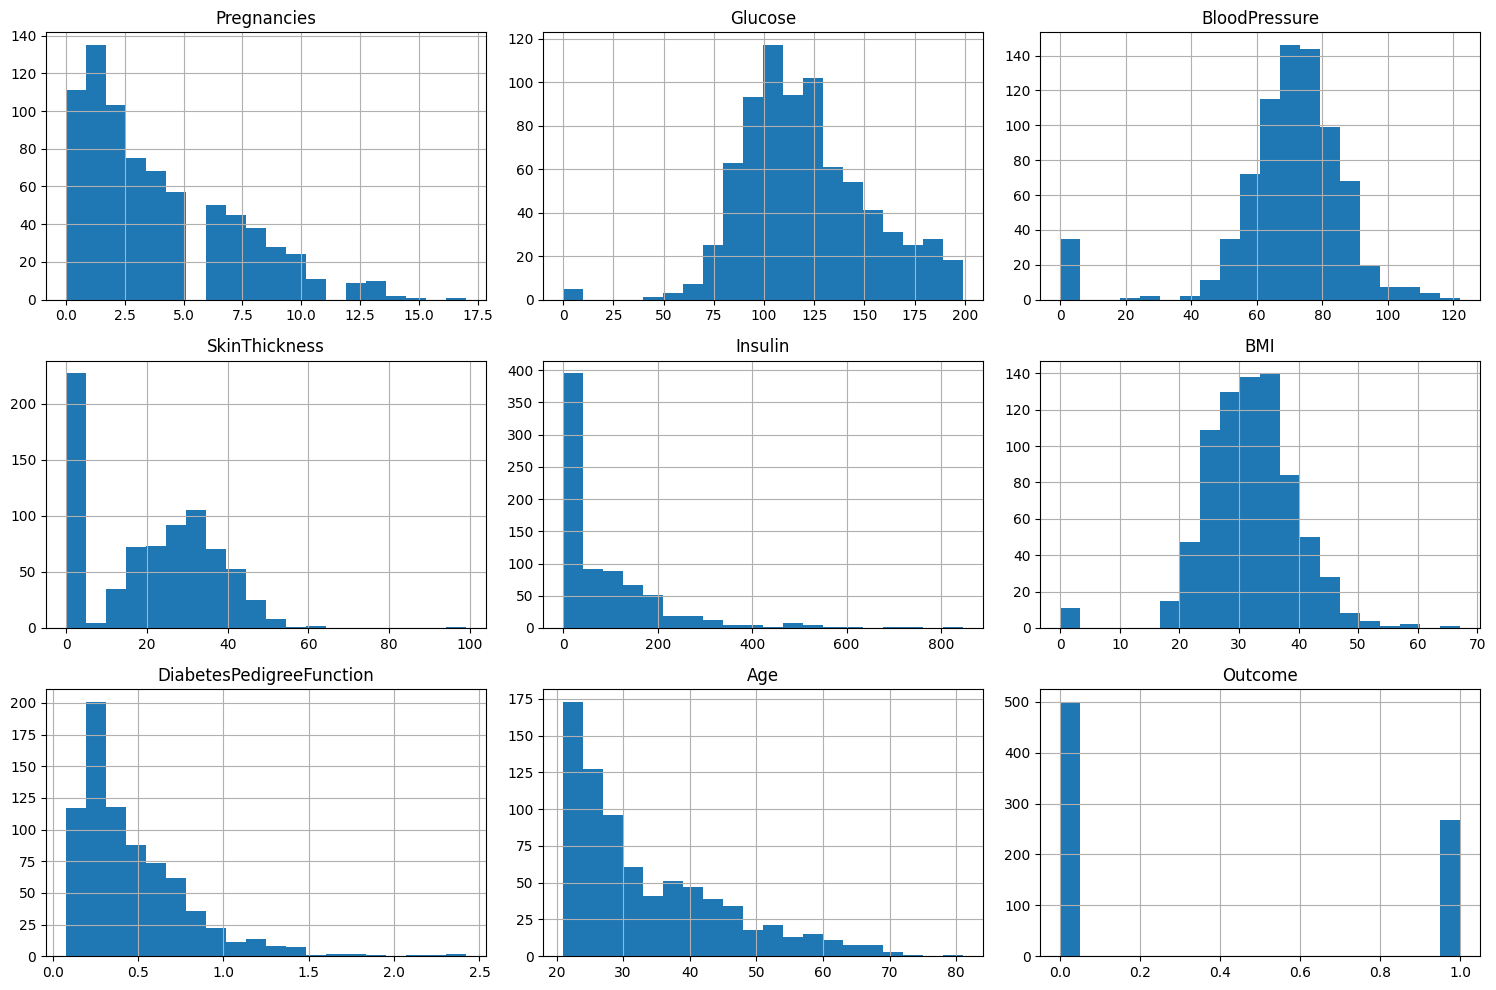

✅ ✅ Histograms printed successfully! completed successfully


In [52]:
# ======================================
#9.2.  Histogram
# ======================================

if show_histograms:
    data.hist(figsize=(15,10), bins=20)
    plt.tight_layout()
    plt.show()

#Completion message
completion_message("✅ Histograms printed successfully!")


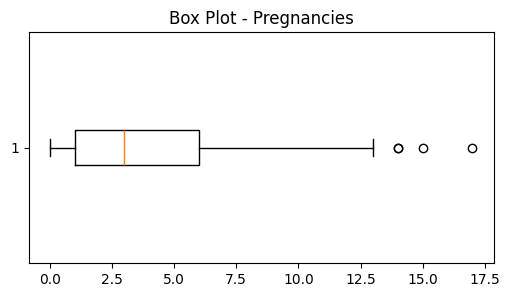

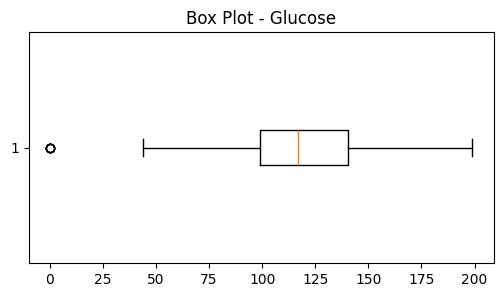

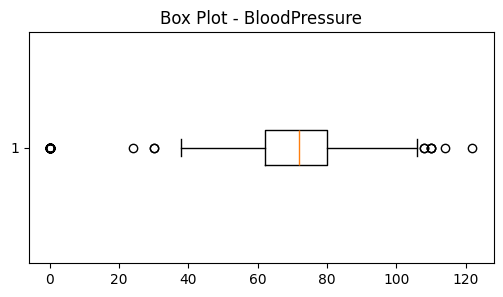

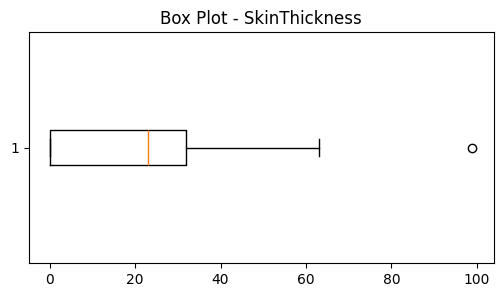

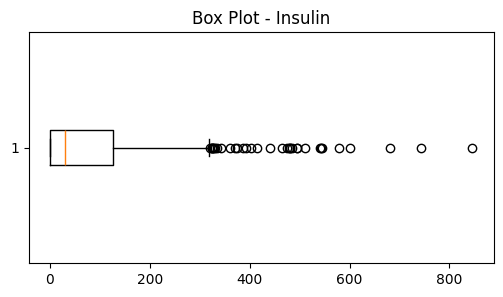

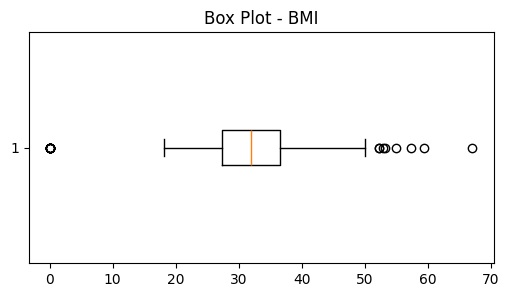

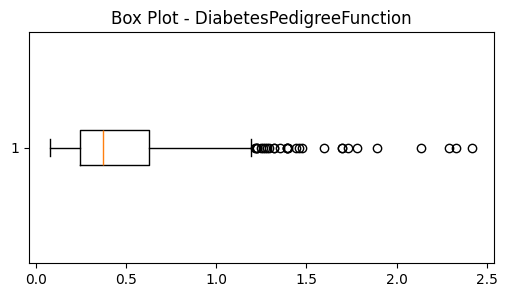

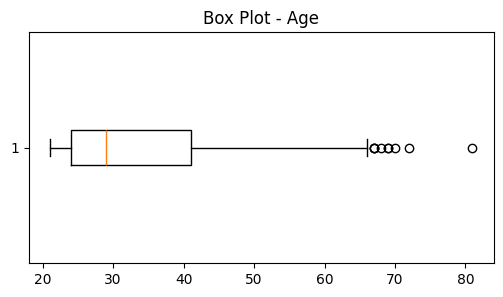

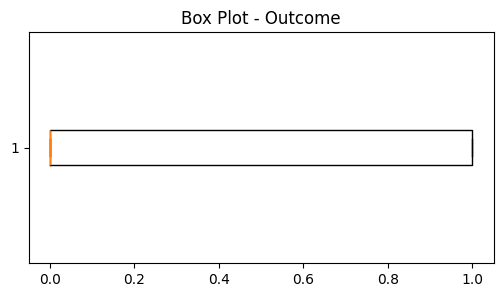

✅ ✅ Box plots printed successfully! completed successfully


In [42]:
# ======================================
#9.3. Box Plots (Outlier Detection)
# ======================================

if show_boxplots:
    numeric_columns = data.select_dtypes(include=np.number).columns

    for column in numeric_columns:
        plt.figure(figsize=(6,3))
        plt.boxplot(data[column].dropna(), vert=False)
        plt.title(f"Box Plot - {column}")
        plt.show()

#Completion message
completion_message("✅ Box plots printed successfully!")


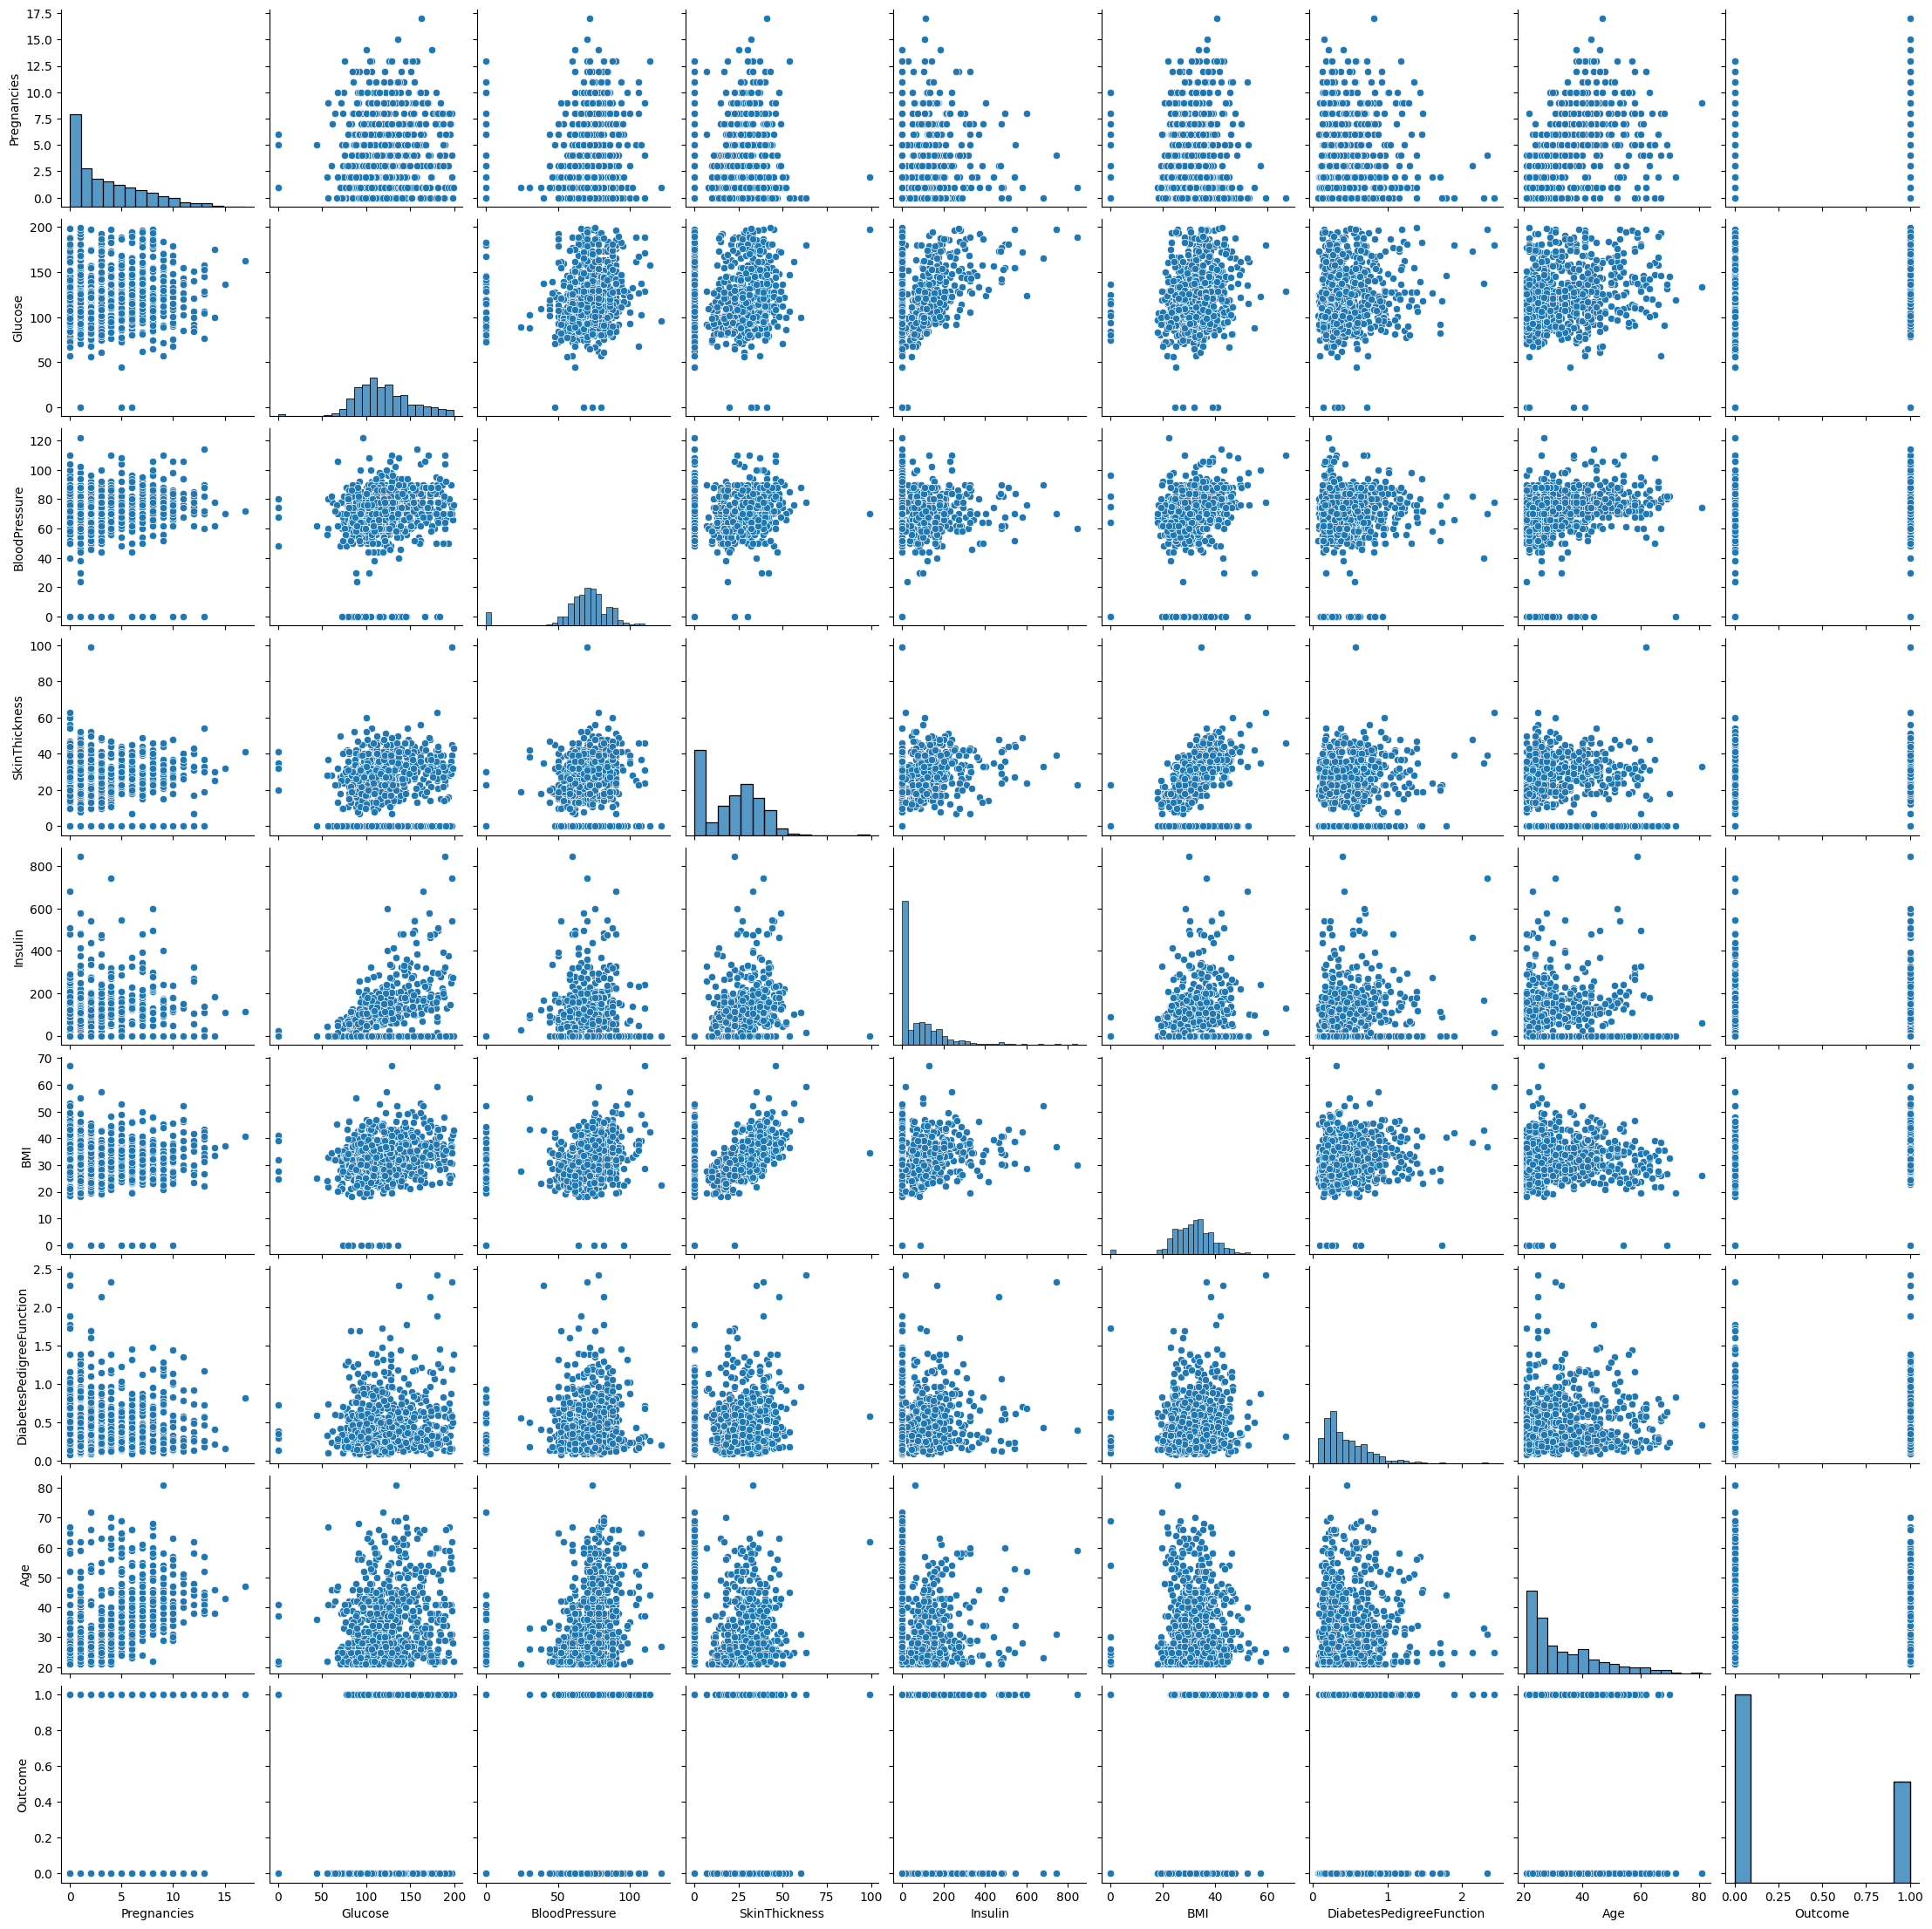

✅ ✅ Pair plot printed successfully! completed successfully


In [45]:
# ======================================
#9.4. Pair Plot (Optional)
# ======================================

if show_pairplot:
    sns.pairplot(data)
    plt.show()

#Completion message
completion_message("✅ Pair plot printed successfully!")


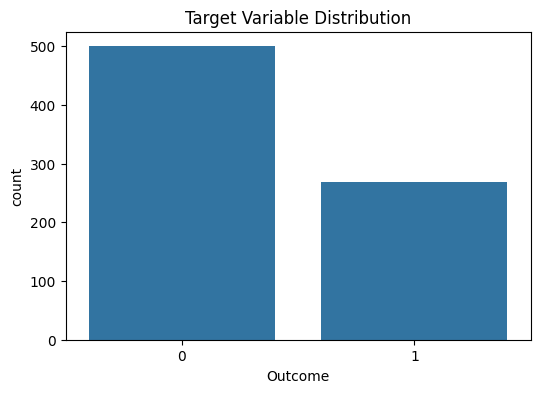

✅ ✅ Target variable distribution printed successfully! completed successfully
✅ ✅ EDA completed successfully completed successfully
✅ SECTION 9 COMPLETED - EDA


In [69]:
# ======================================
#9.5. Target Variable Distribution (Classification)
# ======================================

unique_values = df[target].nunique()

if unique_values <= 20:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=target,
        data=df
    )

    plt.title("Target Variable Distribution")

    plt.show()

else:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[target],
        kde=True
    )

    plt.title("Target Variable Distribution")

    plt.show()


#Completion message
completion_message("✅ Target variable distribution printed successfully!")

#Completion message
completion_message("✅ EDA completed successfully")

section_end(9, "EDA")

In [73]:
# ======================================
#10. Automatic Prolem Type Detection
# ======================================

print("Starting problem type detection...")

target_dtype = df[target].dtype
unique_values = df[target].nunique()

if target_dtype == "object":
    problem_type = "classification"

elif str(target_dtype).startswith(("int", "bool")) and unique_values <= 20:
    problem_type = "classification"

else:
    problem_type = "regression"

print(f"Detected Problem Type: {problem_type}")


completion_message("✅ Problem type detected successfully!")

section_end(10, "Problem Type Detection")

Starting problem type detection...
Detected Problem Type: classification
✅ ✅ Problem type detected successfully! completed successfully
✅ SECTION 10 COMPLETED - PROBLEM TYPE DETECTION


In [74]:
# ======================================
# 11. FEATURE ENGINEERING & PREPROCESSING
# ======================================

# Work on a copy
data = df_clean

#Completion message
completion_message("✅ Data loaded for preprocessing successfully!")

# Separate Features and Target
X = df.drop(columns=[target])
y = df[target]

#Completion message
completion_message("✅ Features and target separated successfully!")

#Verification output
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

#Completion message
completion_message("✅ Verification completed successfully!")

#Completion message
completion_message("✅ Features and target separated successfully!")

✅ ✅ Data loaded for preprocessing successfully! completed successfully
✅ ✅ Features and target separated successfully! completed successfully
Features Shape: (768, 8)
Target Shape: (768,)
✅ ✅ Verification completed successfully! completed successfully
✅ ✅ Features and target separated successfully! completed successfully


In [54]:
# ======================================
#11.1. Identify Column Types
# ======================================
# Numeric Columns
numeric_columns = X.select_dtypes(include=['number']).columns.tolist()

# Categorical Columns
categorical_columns = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

#Completion message
completion_message("✅ Column types identified successfully!")


Numeric Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Categorical Columns:
[]
✅ ✅ Column types identified successfully! completed successfully


In [55]:
# ======================================
#11.2. Handle Missing Values
# ======================================

# Numeric → Median
if len(numeric_columns) > 0:
    X[numeric_columns] = X[numeric_columns].fillna(
        X[numeric_columns].median()
    )

# Categorical → Mode
if len(categorical_columns) > 0:
    for col in categorical_columns:
        X[col] = X[col].fillna(X[col].mode()[0])

#Completion message
completion_message("✅ Missing values handled successfully!")

✅ ✅ Missing values handled successfully! completed successfully


In [56]:
# ======================================
#11.3. One-Hot Encode Categorical Columns
# ======================================

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

#Completion message
completion_message("✅ Categorical columns one-hot encoded successfully!")

✅ ✅ Categorical columns one-hot encoded successfully! completed successfully


In [57]:
# ======================================
#11.4. Encode Target (Only for Classification)
# ======================================

if problem_type == "classification" and y.dtype == "object":
    encoder = LabelEncoder()
    y = encoder.fit_transform(y)

#Completion message
completion_message("✅ Target encoded successfully!")

✅ ✅ Target encoded successfully! completed successfully


In [58]:
# ======================================
#11.5. Feature Scaling
# ======================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

#Completion message
completion_message("✅ Features scaled successfully!")

✅ ✅ Features scaled successfully! completed successfully


In [59]:
# ======================================
#11.6. Final Verification
# ======================================

print("Final Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

#Completion message
completion_message("✅ Final verification completed successfully!")

#Completion message
completion_message("✅ Preprocessing completed successfully!")

section_end(11, "Preprocessing")

Final Feature Matrix Shape: (768, 8)
Target Shape: (768,)
✅ ✅ Final verification completed successfully! completed successfully
✅ ✅ Preprocessing completed successfully! completed successfully
✅ SECTION 10 COMPLETED - PREPROCESSING


In [60]:
# ======================================
# 12. TRAIN-TEST SPLIT
# ======================================

if problem_type == "classification":

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

else:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

#Completion message
completion_message("✅ Train-Test split completed successfully!")

✅ ✅ Train-Test split completed successfully! completed successfully


In [61]:
# ======================================
# Verify Train/Test Split
# ======================================

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

#Completion message
completion_message("✅ Train-Test split verification completed successfully!")

section_end(12, "Train-Test Split")

Training Features : (614, 8)
Testing Features  : (154, 8)
Training Target   : (614,)
Testing Target    : (154,)
✅ ✅ Train-Test split verification completed successfully! completed successfully
✅ SECTION 11 COMPLETED - TRAIN-TEST SPLIT


In [75]:
# ======================================
# 13. MODEL DEFINITION
# ======================================

models = {}

if problem_type == "classification":

    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import (
        RandomForestClassifier,
        GradientBoostingClassifier,
        AdaBoostClassifier,
        ExtraTreesClassifier
    )
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.naive_bayes import GaussianNB

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000
        ),

        "Decision Tree": DecisionTreeClassifier(),

        "Random Forest": RandomForestClassifier(),

        "Extra Trees": ExtraTreesClassifier(),

        "Gradient Boosting": GradientBoostingClassifier(),

        "AdaBoost": AdaBoostClassifier(),

        "Support Vector Machine": SVC(
            probability=True
        ),

        "K-Nearest Neighbors": KNeighborsClassifier(),

        "Naive Bayes": GaussianNB()
    }


elif problem_type == "regression":

    from sklearn.linear_model import (
        LinearRegression,
        Ridge,
        Lasso
    )
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import (
        RandomForestRegressor,
        GradientBoostingRegressor,
        AdaBoostRegressor,
        ExtraTreesRegressor
    )
    from sklearn.svm import SVR
    from sklearn.neighbors import KNeighborsRegressor

    models = {

        "Linear Regression": LinearRegression(),

        "Ridge Regression": Ridge(),

        "Lasso Regression": Lasso(),

        "Decision Tree": DecisionTreeRegressor(),

        "Random Forest": RandomForestRegressor(),

        "Extra Trees": ExtraTreesRegressor(),

        "Gradient Boosting": GradientBoostingRegressor(),

        "AdaBoost": AdaBoostRegressor(),

        "Support Vector Regression": SVR(),

        "K-Nearest Neighbors": KNeighborsRegressor()
    }


print("Available Models:")
for name in models:
    print("✓", name)


#Completion message
completion_message("Model definition")

section_end(13, "Model Definition")

Available Models:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Extra Trees
✓ Gradient Boosting
✓ AdaBoost
✓ Support Vector Machine
✓ K-Nearest Neighbors
✓ Naive Bayes
✅ Model definition completed successfully
✅ SECTION 13 COMPLETED - MODEL DEFINITION


In [76]:
# ======================================
# 14. MODEL TRAINING
# ======================================

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"✅ {name} completed")


section_end(14, "Model Training")

Training Logistic Regression...
✅ Logistic Regression completed
Training Decision Tree...
✅ Decision Tree completed
Training Random Forest...
✅ Random Forest completed
Training Extra Trees...
✅ Extra Trees completed
Training Gradient Boosting...
✅ Gradient Boosting completed
Training AdaBoost...
✅ AdaBoost completed
Training Support Vector Machine...
✅ Support Vector Machine completed
Training K-Nearest Neighbors...
✅ K-Nearest Neighbors completed
Training Naive Bayes...
✅ Naive Bayes completed
✅ SECTION 14 COMPLETED - MODEL TRAINING


In [77]:
# ======================================
# 15. MODEL EVALUATION
# ======================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd


results = []


for name, model in trained_models.items():

    y_pred = model.predict(X_test)


    if problem_type == "classification":

        report = classification_report(
            y_test,
            y_pred,
            output_dict=True
        )

        cm = confusion_matrix(
            y_test,
            y_pred
        )


        results.append({

            "Model": name,

            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "Precision": precision_score(
                y_test,
                y_pred,
                average="weighted"
            ),

            "Recall": recall_score(
                y_test,
                y_pred,
                average="weighted"
            ),

            "F1 Score": f1_score(
                y_test,
                y_pred,
                average="weighted"
            ),

            "Macro Avg": report["macro avg"]["f1-score"],

            "Weighted Avg": report["weighted avg"]["f1-score"],

            "Confusion Matrix": cm

        })


    elif problem_type == "regression":

        results.append({

            "Model": name,

            "MAE": mean_absolute_error(
                y_test,
                y_pred
            ),

            "RMSE": mean_squared_error(
                y_test,
                y_pred,
                squared=False
            ),

            "R2 Score": r2_score(
                y_test,
                y_pred
            )

        })


evaluation_results = pd.DataFrame(results)


display(evaluation_results)


completion_message("Model evaluation")

section_end(15, "Model Evaluation")

,Model,Accuracy,Precision,Recall,F1 Score,Macro Avg,Weighted Avg,Confusion Matrix
0,Logistic Regression,0.753247,0.755394,0.753247,0.754191,0.733418,0.754191,"[[79, 20], [18, 37]]"
1,Decision Tree,0.746753,0.758929,0.746753,0.750300,0.732960,0.750300,"[[75, 24], [15, 40]]"
2,Random Forest,0.753247,0.757844,0.753247,0.755032,0.735395,0.755032,"[[78, 21], [17, 38]]"
3,Extra Trees,0.746753,0.741465,0.746753,0.742471,0.715558,0.742471,"[[83, 16], [23, 32]]"
4,Gradient Boosting,0.746753,0.750154,0.746753,0.748167,0.727434,0.748167,"[[78, 21], [18, 37]]"
5,AdaBoost,0.779221,0.783484,0.779221,0.780818,0.763248,0.780818,"[[80, 19], [15, 40]]"
6,Support Vector Machine,0.727273,0.721866,0.727273,0.723416,0.695136,0.723416,"[[81, 18], [24, 31]]"
7,K-Nearest Neighbors,0.688312,0.679800,0.688312,0.682141,0.648201,0.682141,"[[79, 20], [28, 27]]"
8,Naive Bayes,0.766234,0.770664,0.766234,0.767925,0.749322,0.767925,"[[79, 20], [16, 39]]"


✅ Model evaluation completed successfully
✅ SECTION 15 COMPLETED - MODEL EVALUATION


In [78]:
# ======================================
# 16. MODEL COMPARISON
# ======================================

if "evaluation_results" not in globals():
    raise NameError(
        "evaluation_results not found. Run Model Evaluation section first."
    )


if problem_type == "classification":

    comparison_results = evaluation_results.sort_values(
        by="Accuracy",
        ascending=False
    )


elif problem_type == "regression":

    comparison_results = evaluation_results.sort_values(
        by="RMSE",
        ascending=True
    )


# Select best model

best_model_name = comparison_results.iloc[0]["Model"]


print("=" * LINE)

print("MODEL RANKING")

display(comparison_results)

print("=" * LINE)

print(
    f"🏆 Best Model Selected: {best_model_name}"
)

print("=" * LINE)


# Completion message

completion_message("Model comparison")

section_end(16, "Model Comparison")

MODEL RANKING


,Model,Accuracy,Precision,Recall,F1 Score,Macro Avg,Weighted Avg,Confusion Matrix
5,AdaBoost,0.779221,0.783484,0.779221,0.780818,0.763248,0.780818,"[[80, 19], [15, 40]]"
8,Naive Bayes,0.766234,0.770664,0.766234,0.767925,0.749322,0.767925,"[[79, 20], [16, 39]]"
0,Logistic Regression,0.753247,0.755394,0.753247,0.754191,0.733418,0.754191,"[[79, 20], [18, 37]]"
2,Random Forest,0.753247,0.757844,0.753247,0.755032,0.735395,0.755032,"[[78, 21], [17, 38]]"
1,Decision Tree,0.746753,0.758929,0.746753,0.750300,0.732960,0.750300,"[[75, 24], [15, 40]]"
4,Gradient Boosting,0.746753,0.750154,0.746753,0.748167,0.727434,0.748167,"[[78, 21], [18, 37]]"
3,Extra Trees,0.746753,0.741465,0.746753,0.742471,0.715558,0.742471,"[[83, 16], [23, 32]]"
6,Support Vector Machine,0.727273,0.721866,0.727273,0.723416,0.695136,0.723416,"[[81, 18], [24, 31]]"
7,K-Nearest Neighbors,0.688312,0.679800,0.688312,0.682141,0.648201,0.682141,"[[79, 20], [28, 27]]"


🏆 Best Model Selected: AdaBoost
✅ Model comparison completed successfully
✅ SECTION 16 COMPLETED - MODEL COMPARISON


In [79]:
# ======================================
# 17. BEST MODEL VALIDATION / ERROR ANALYSIS
# ======================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np


# Select best model from Section 15

final_candidate_model = trained_models[best_model_name]


print("=" * LINE)
print(f"BEST MODEL SELECTED: {best_model_name}")
print("=" * LINE)


# -----------------------------
# Predictions
# -----------------------------

train_prediction = final_candidate_model.predict(X_train)

test_prediction = final_candidate_model.predict(X_test)


# -----------------------------
# Performance comparison
# -----------------------------

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)


print("\nTRAIN VS TEST PERFORMANCE")

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")


# -----------------------------
# Classification Report
# -----------------------------

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        test_prediction
    )
)


# -----------------------------
# Confusion Matrix
# -----------------------------

print("\nCONFUSION MATRIX")

cm = confusion_matrix(
    y_test,
    test_prediction
)

print(cm)


# -----------------------------
# Automatic Model Health Check
# -----------------------------

print("\nMODEL HEALTH CHECK")

performance_gap = train_accuracy - test_accuracy


if performance_gap > 0.10:

    print(
        "⚠️ Possible overfitting detected"
    )

elif train_accuracy < 0.75 and test_accuracy < 0.75:

    print(
        "⚠️ Possible underfitting detected"
    )

else:

    print(
        "✅ Model generalization looks acceptable"
    )


# Recall check (important for healthcare)

test_recall = recall_score(
    y_test,
    test_prediction,
    average="weighted"
)


if test_recall < 0.80:

    print(
        "⚠️ Recall is low - consider improvement"
    )

else:

    print(
        "✅ Recall performance acceptable"
    )


# Final recommendation

print("\nRECOMMENDATION")

if performance_gap > 0.10 or test_recall < 0.80:

    print(
        "➡️ Consider hyperparameter tuning or feature improvement"
    )

else:

    print(
        "➡️ Model is ready for finalization"
    )

# ======================================
# IMPROVEMENT DECISION FLAG
# ======================================

improvement_needed = False


if performance_gap > 0.10 or test_recall < 0.80:

    improvement_needed = True


print(
    "Improvement Required:",
    improvement_needed
)

#Completion message
completion_message("Best Model Validation / Error Analysis")

#Section end
section_end(17, "Best Model Validation / Error Analysis")

BEST MODEL SELECTED: AdaBoost

TRAIN VS TEST PERFORMANCE
Training Accuracy : 0.8029
Testing Accuracy  : 0.7792

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        99
           1       0.68      0.73      0.70        55

    accuracy                           0.78       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.78      0.78      0.78       154


CONFUSION MATRIX
[[80 19]
 [15 40]]

MODEL HEALTH CHECK
✅ Model generalization looks acceptable
⚠️ Recall is low - consider improvement

RECOMMENDATION
➡️ Consider hyperparameter tuning or feature improvement
Improvement Required: True
✅ Best Model Validation / Error Analysis completed successfully
✅ SECTION 17 COMPLETED - BEST MODEL VALIDATION / ERROR ANALYSIS


In [82]:
# ======================================
# 18.0. HYPERPARAMETER OPTIMIZATION LIBRARY
# ======================================

optimization_grids = {}


# ======================================
# CLASSIFICATION MODELS
# ======================================

if problem_type == "classification":

    optimization_grids = {


        "Logistic Regression": {

            "C": [
                0.01,
                0.1,
                1,
                10
            ],

            "solver": [
                "liblinear",
                "lbfgs"
            ]

        },


        "Decision Tree": {

            "max_depth": [
                3,
                5,
                10,
                None
            ],

            "min_samples_split": [
                2,
                5,
                10
            ],

            "criterion": [
                "gini",
                "entropy"
            ]

        },


        "Random Forest": {

            "n_estimators": [
                100,
                200,
                300
            ],

            "max_depth": [
                5,
                10,
                15,
                None
            ],

            "min_samples_split": [
                2,
                5,
                10
            ],

            "criterion": [
                "gini",
                "entropy"
            ]

        },


        "Extra Trees": {

            "n_estimators": [
                100,
                200
            ],

            "max_depth": [
                5,
                10,
                None
            ]

        },


        "Gradient Boosting": {

            "n_estimators": [
                100,
                200
            ],

            "learning_rate": [
                0.01,
                0.05,
                0.1
            ],

            "max_depth": [
                3,
                5
            ]

        },


        "AdaBoost": {

            "n_estimators": [
                50,
                100,
                200
            ],

            "learning_rate": [
                0.01,
                0.1,
                1
            ]

        },


        "Support Vector Machine": {

            "C": [
                0.1,
                1,
                10
            ],

            "kernel": [
                "linear",
                "rbf"
            ]

        },


        "K-Nearest Neighbors": {

            "n_neighbors": [
                3,
                5,
                7,
                9
            ],

            "weights": [
                "uniform",
                "distance"
            ]

        },


        "Naive Bayes": {

            "var_smoothing": [
                1e-9,
                1e-8,
                1e-7
            ]

        }

    }



# ======================================
# REGRESSION MODELS
# ======================================

elif problem_type == "regression":

    optimization_grids = {


        "Linear Regression": {

        },


        "Ridge Regression": {

            "alpha": [
                0.01,
                0.1,
                1,
                10
            ]

        },


        "Lasso Regression": {

            "alpha": [
                0.01,
                0.1,
                1,
                10
            ]

        },


        "Decision Tree": {

            "max_depth": [
                3,
                5,
                10,
                None
            ],

            "min_samples_split": [
                2,
                5,
                10
            ]

        },


        "Random Forest": {

            "n_estimators": [
                100,
                200,
                300
            ],

            "max_depth": [
                5,
                10,
                None
            ],

            "min_samples_split": [
                2,
                5,
                10
            ]

        },


        "Extra Trees": {

            "n_estimators": [
                100,
                200
            ],

            "max_depth": [
                5,
                10,
                None
            ]

        },


        "Gradient Boosting": {

            "n_estimators": [
                100,
                200
            ],

            "learning_rate": [
                0.01,
                0.05,
                0.1
            ]

        },


        "AdaBoost": {

            "n_estimators": [
                50,
                100,
                200
            ],

            "learning_rate": [
                0.01,
                0.1,
                1
            ]

        },


        "Support Vector Regression": {

            "C": [
                0.1,
                1,
                10
            ],

            "kernel": [
                "linear",
                "rbf"
            ]

        },


        "K-Nearest Neighbors": {

            "n_neighbors": [
                3,
                5,
                7,
                9
            ]

        }

    }



print("=" * LINE)

print("Available Optimization Models:")

for model_name in optimization_grids:

    print("✓", model_name)


print("=" * LINE)


completion_message(
    "Hyperparameter optimization library created"
)

section_end(
    18,
    "Hyperparameter Optimization"
)


Available Optimization Models:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Extra Trees
✓ Gradient Boosting
✓ AdaBoost
✓ Support Vector Machine
✓ K-Nearest Neighbors
✓ Naive Bayes
✅ Hyperparameter optimization library created completed successfully
✅ SECTION 18 COMPLETED - HYPERPARAMETER OPTIMIZATION


In [83]:
# ======================================
# 18.1 HYPERPARAMETER OPTIMIZATION EXECUTION
# ======================================

from sklearn.model_selection import GridSearchCV


#Create final model if missing
if "final_model" not in globals():

    if "best_model_name" in globals():

        final_model = trained_models[best_model_name]

    else:

        raise Exception(
            "Best model not selected before optimization"
        )


optimized_model = final_model

optimization_applied = False

print("Selected Model:", best_model_name)
print("Model Object:", type(final_model).__name__)
print("Improvement Needed:", improvement_needed)


if improvement_needed:

    print("=" * LINE)
    print("Starting Hyperparameter Optimization")
    print("=" * LINE)


    if best_model_name in optimization_grids:


        param_grid = optimization_grids[best_model_name]


        if len(param_grid) > 0:


            print(
                "Optimizing Model:",
                best_model_name
            )


            # Scoring selection

            if problem_type == "classification":

                scoring_metric = "f1_weighted"


            else:

                scoring_metric = "neg_root_mean_squared_error"



            optimizer = GridSearchCV(

                estimator=final_model,

                param_grid=param_grid,

                cv=cv_folds,

                scoring=scoring_metric,

                n_jobs=-1

            )


            optimizer.fit(

                X_train,

                y_train

            )


            optimized_model = optimizer.best_estimator_

            optimization_applied = True


            print("=" * LINE)

            print(
                "Best Parameters:"
            )

            print(
                optimizer.best_params_
            )


            print(
                "✅ Optimization Completed"
            )


        else:

            print(
                "No parameters available for this model"
            )


    else:

        print(
            "Optimization grid not available for:",
            best_model_name
        )


else:


    print("=" * LINE)

    print(
        "⏭️ Optimization Skipped"
    )

    print(
        "Reason: Performance acceptable"
    )

    print("=" * LINE)


#Completion message
completion_message(
    "Hyperparameter optimization execution completed"
)

#Section ends
section_end(
    18.1,
    "Hyperparameter Optimization"
)

Selected Model: AdaBoost
Model Object: AdaBoostClassifier
Improvement Needed: True
Starting Hyperparameter Optimization
Optimizing Model: AdaBoost
Best Parameters:
{'learning_rate': 1, 'n_estimators': 100}
✅ Optimization Completed
✅ Hyperparameter optimization execution completed completed successfully
✅ SECTION 18.1 COMPLETED - HYPERPARAMETER OPTIMIZATION


In [84]:
# ======================================
# 19. OPTIMIZED MODEL EVALUATION & COMPARISON
# ======================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd


comparison_results = []


# ======================================
# Evaluate Original Model
# ======================================

original_prediction = final_model.predict(X_test)


if problem_type == "classification":

    original_accuracy = accuracy_score(
        y_test,
        original_prediction
    )

    original_precision = precision_score(
        y_test,
        original_prediction,
        average="weighted"
    )

    original_recall = recall_score(
        y_test,
        original_prediction,
        average="weighted"
    )

    original_f1 = f1_score(
        y_test,
        original_prediction,
        average="weighted"
    )


    comparison_results.append({

        "Model": "Original Best Model",

        "Accuracy": original_accuracy,

        "Precision": original_precision,

        "Recall": original_recall,

        "F1 Score": original_f1

    })


else:

    original_mae = mean_absolute_error(
        y_test,
        original_prediction
    )

    original_rmse = mean_squared_error(
        y_test,
        original_prediction,
        squared=False
    )

    original_r2 = r2_score(
        y_test,
        original_prediction
    )


    comparison_results.append({

        "Model": "Original Best Model",

        "MAE": original_mae,

        "RMSE": original_rmse,

        "R2 Score": original_r2

    })



# ======================================
# Evaluate Optimized Model
# ======================================

optimized_prediction = optimized_model.predict(X_test)


if problem_type == "classification":

    optimized_accuracy = accuracy_score(
        y_test,
        optimized_prediction
    )

    optimized_precision = precision_score(
        y_test,
        optimized_prediction,
        average="weighted"
    )

    optimized_recall = recall_score(
        y_test,
        optimized_prediction,
        average="weighted"
    )

    optimized_f1 = f1_score(
        y_test,
        optimized_prediction,
        average="weighted"
    )


    comparison_results.append({

        "Model": "Optimized Model",

        "Accuracy": optimized_accuracy,

        "Precision": optimized_precision,

        "Recall": optimized_recall,

        "F1 Score": optimized_f1

    })


else:

    optimized_mae = mean_absolute_error(
        y_test,
        optimized_prediction
    )

    optimized_rmse = mean_squared_error(
        y_test,
        optimized_prediction,
        squared=False
    )

    optimized_r2 = r2_score(
        y_test,
        optimized_prediction
    )


    comparison_results.append({

        "Model": "Optimized Model",

        "MAE": optimized_mae,

        "RMSE": optimized_rmse,

        "R2 Score": optimized_r2

    })



# ======================================
# Comparison Table
# ======================================

optimization_comparison = pd.DataFrame(
    comparison_results
)


print("=" * LINE)

print("MODEL PERFORMANCE COMPARISON")

print("=" * LINE)

display(
    optimization_comparison
)



# ======================================
# Select Final Model
# ======================================

if problem_type == "classification":

    if optimized_f1 >= original_f1:

        final_selected_model = optimized_model

        print(
            "🏆 Optimized Model Selected"
        )

    else:

        final_selected_model = final_model

        print(
            "🏆 Original Model Selected"
        )


else:

    if optimized_rmse <= original_rmse:

        final_selected_model = optimized_model

        print(
            "🏆 Optimized Model Selected"
        )

    else:

        final_selected_model = final_model

        print(
            "🏆 Original Model Selected"
        )


#Completion message
completion_message(
    "Optimized model evaluation and comparison completed"
)

#Sections ends
section_end(
    19,
    "Optimized Model Evaluation & Comparison"
)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Original Best Model,0.779221,0.783484,0.779221,0.780818
1,Optimized Model,0.740260,0.745024,0.740260,0.742139


🏆 Original Model Selected
✅ Optimized model evaluation and comparison completed completed successfully
✅ SECTION 19 COMPLETED - OPTIMIZED MODEL EVALUATION & COMPARISON


In [86]:
# ======================================
# 20. FINAL MODEL PERFORMANCE REPORT
# ======================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
from datetime import datetime


print("=" * LINE)
print("FINAL MODEL PERFORMANCE REPORT")
print("=" * LINE)


# Model information

final_model_name = type(final_selected_model).__name__

report_data = {

    "Project Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "Problem Type": problem_type,

    "Final Model": final_model_name

}


# ======================================
# Prediction
# ======================================

final_prediction = final_selected_model.predict(
    X_test
)



# ======================================
# Classification Report
# ======================================

if problem_type == "classification":


    accuracy = accuracy_score(
        y_test,
        final_prediction
    )


    precision = precision_score(
        y_test,
        final_prediction,
        average="weighted"
    )


    recall = recall_score(
        y_test,
        final_prediction,
        average="weighted"
    )


    f1 = f1_score(
        y_test,
        final_prediction,
        average="weighted"
    )


    report_data.update({

        "Accuracy": round(accuracy,4),

        "Precision": round(precision,4),

        "Recall": round(recall,4),

        "F1 Score": round(f1,4)

    })



# ======================================
# Regression Report
# ======================================

else:


    mae = mean_absolute_error(
        y_test,
        final_prediction
    )


    rmse = mean_squared_error(
        y_test,
        final_prediction,
        squared=False
    )


    r2 = r2_score(
        y_test,
        final_prediction
    )


    report_data.update({

        "MAE": round(mae,4),

        "RMSE": round(rmse,4),

        "R2 Score": round(r2,4)

    })



# ======================================
# Create Report Table
# ======================================

final_report = pd.DataFrame(
    report_data,
    index=[0]
)



print()

display(
    final_report
)


print("=" * LINE)

print(
    "✅ Final model report generated successfully"
)

print("=" * LINE)



completion_message(
    "Final Model Performance Report completed"
)


section_end(
    20,
    "Final Model Performance Report"
)

FINAL MODEL PERFORMANCE REPORT



,Project Date,Problem Type,Final Model,Accuracy,Precision,Recall,F1 Score
0,2026-08-01 17:11:12,classification,AdaBoostClassifier,0.7792,0.7835,0.7792,0.7808


✅ Final model report generated successfully
✅ Final Model Performance Report completed completed successfully
✅ SECTION 20 COMPLETED - FINAL MODEL PERFORMANCE REPORT


FEATURE IMPORTANCE ANALYSIS
Top Features:


,Feature,Importance
1,Glucose,0.307137
7,Age,0.239930
5,BMI,0.238076
6,DiabetesPedigreeFunction,0.168234
2,BloodPressure,0.025736
4,Insulin,0.020887
3,SkinThickness,0.000000
0,Pregnancies,0.000000


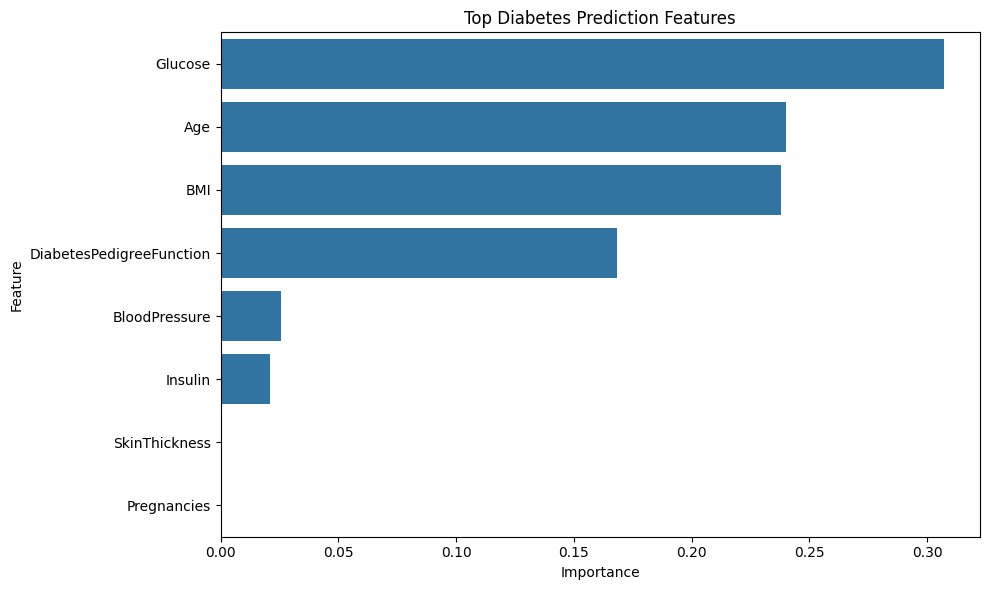

✅ Diabetes feature importance analysis completed completed successfully
✅ SECTION 21 COMPLETED - FEATURE IMPORTANCE / MODEL INTERPRETATION


In [88]:
# ======================================
# 21. FEATURE IMPORTANCE / MODEL INTERPRETATION
# ======================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance


print("=" * LINE)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * LINE)


model = final_selected_model


# ======================================
# Diabetes Dataset Feature Names
# ======================================

diabetes_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]


# Use actual dataframe columns if available

if hasattr(X_train, "columns"):

    feature_names = X_train.columns

else:

    feature_names = diabetes_features



# ======================================
# Tree Based Models
# ======================================

if hasattr(model, "feature_importances_"):

    importance_values = model.feature_importances_


    importance_df = pd.DataFrame({

        "Feature": feature_names,

        "Importance": importance_values

    })



# ======================================
# Linear Models
# ======================================

elif hasattr(model, "coef_"):

    coefficients = model.coef_


    if len(coefficients.shape) > 1:

        coefficients = coefficients[0]


    importance_df = pd.DataFrame({

        "Feature": feature_names,

        "Importance": abs(coefficients)

    })



# ======================================
# Other Models
# ======================================

else:

    print("Using permutation importance...")


    permutation = permutation_importance(

        model,

        X_test,

        y_test,

        n_repeats=10,

        random_state=42

    )


    importance_df = pd.DataFrame({

        "Feature": feature_names,

        "Importance": permutation.importances_mean

    })



# ======================================
# Sort Features
# ======================================

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)



print("Top Features:")

display(
    importance_df
)



# ======================================
# Top 10 Feature Plot
# ======================================

top_features = importance_df.head(10)


plt.figure(figsize=(10,6))


sns.barplot(

    data=top_features,

    x="Importance",

    y="Feature"

)


plt.title(
    "Top Diabetes Prediction Features"
)


plt.tight_layout()


plt.show()



#Completion message
completion_message(
    "Diabetes feature importance analysis completed"
)

#Section ends
section_end(
    21,
    "Feature Importance / Model Interpretation"
)

In [93]:
# ======================================
# 22. FINAL MODEL SAVING
# ======================================

import joblib
import os
import json
from datetime import datetime
from google.colab import drive


print("=" * LINE)
print("FINAL MODEL SAVING")
print("=" * LINE)


# ======================================
# Save Location Selection
# ======================================

save_to_drive = input(
    "Save to Google Drive? (yes/no): "
)


if save_to_drive.lower() == "yes":

    drive.mount('/content/drive')

    save_folder = "/content/drive/MyDrive/ML_Projects"


else:

    save_folder = "/content"



os.makedirs(
    save_folder,
    exist_ok=True
)



# ======================================
# Custom Project Name
# ======================================

project_name = input(
    "Enter project/model name: "
)


project_name = project_name.strip().replace(
    " ",
    "_"
)



# ======================================
# File Paths
# ======================================

model_file = os.path.join(
    save_folder,
    project_name + "_model.pkl"
)


feature_file = os.path.join(
    save_folder,
    project_name + "_features.pkl"
)


metadata_file = os.path.join(
    save_folder,
    project_name + "_metadata.json"
)



# ======================================
# Save Model
# ======================================

joblib.dump(

    final_selected_model,

    model_file

)


print(
    "✅ Model saved"
)



# ======================================
# Save Feature List
# ======================================

# Save feature names safely

if hasattr(X_train, "columns"):

    feature_names = list(X_train.columns)

else:

    feature_names = list(X.columns)



joblib.dump(

    feature_names,

    feature_file

)


print(
    "✅ Feature list saved"
)



# ======================================
# Save Metadata
# ======================================

# Get feature names safely

if hasattr(X_train, "columns"):

    feature_names = list(X_train.columns)

else:

    feature_names = list(X.columns)



metadata = {

    "Project Name":
    project_name,


    "Model":
    type(final_selected_model).__name__,


    "Problem Type":
    problem_type,


    "Features":
    feature_names,


    "Created Date":
    datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

}



with open(
    metadata_file,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )


print(
    "✅ Metadata saved"
)



# ======================================
# Verification
# ======================================

print()
print("=" * LINE)
print("FILE VERIFICATION")
print("=" * LINE)



files_to_check = [

    model_file,

    feature_file,

    metadata_file

]


for file in files_to_check:


    if os.path.exists(file):

        print(
            "✅ Exists:",
            file
        )

    else:

        print(
            "❌ Missing:",
            file
        )



print("=" * LINE)


#Completion message
completion_message(
    "Final model saving completed"
)

#Section ends
section_end(
    22,
    "Final Model Saving"
)

FINAL MODEL SAVING
Save to Google Drive? (yes/no): YES
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter project/model name: Diabetes_Risk_Prediction_AdBooster_v1
✅ Model saved
✅ Feature list saved
✅ Metadata saved

FILE VERIFICATION
✅ Exists: /content/drive/MyDrive/ML_Projects/Diabetes_Risk_Prediction_AdBooster_v1_model.pkl
✅ Exists: /content/drive/MyDrive/ML_Projects/Diabetes_Risk_Prediction_AdBooster_v1_features.pkl
✅ Exists: /content/drive/MyDrive/ML_Projects/Diabetes_Risk_Prediction_AdBooster_v1_metadata.json
✅ Final model saving completed completed successfully
✅ SECTION 22 COMPLETED - FINAL MODEL SAVING
